# Brent Oil Price Time Series Exploratory Data Analysis

## Objective

This notebook performs exploratory data analysis on historical Brent crude oil prices.
The goal is to understand price behavior, identify important time series properties,
and prepare the data for future change point modeling.

The analysis focuses on:
- Long-term price trends
- Stationarity
- Volatility patterns
- Structural changes in the oil market

Import Libraries

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

Load Dataset

In [12]:
from src.data_loader import load_data
from src.eda import calculate_log_returns

df = load_data("../data/raw/BrentOilPrices.csv")
df.head()

c:\Users\melim\Documents\Kifiya\brent-oil-analysis\src\data_loader.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


Convert date

In [17]:
import pandas as pd

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

Inspect

In [19]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[us]
 1   Price   9011 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 140.9 KB


,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


Missing values

In [20]:
df.isnull().sum()

Date     0
Price    0
dtype: int64

Raw Price Plot

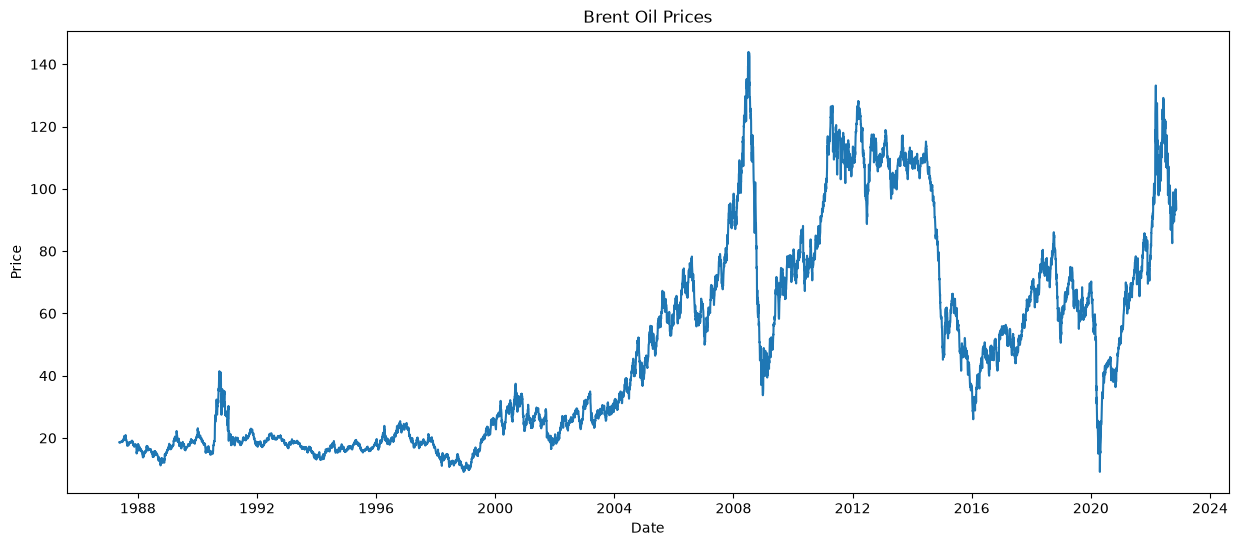

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(df["Date"], df["Price"])
plt.title("Brent Oil Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

This satisfies:

 Brent data loaded
 Raw price visualization

Trend

In [21]:
df["Rolling_Mean"] = df["Price"].rolling(30).mean()

df["Rolling_STD"] = df["Price"].rolling(30).std()

Calculate Log Returns and Log Returns Plot

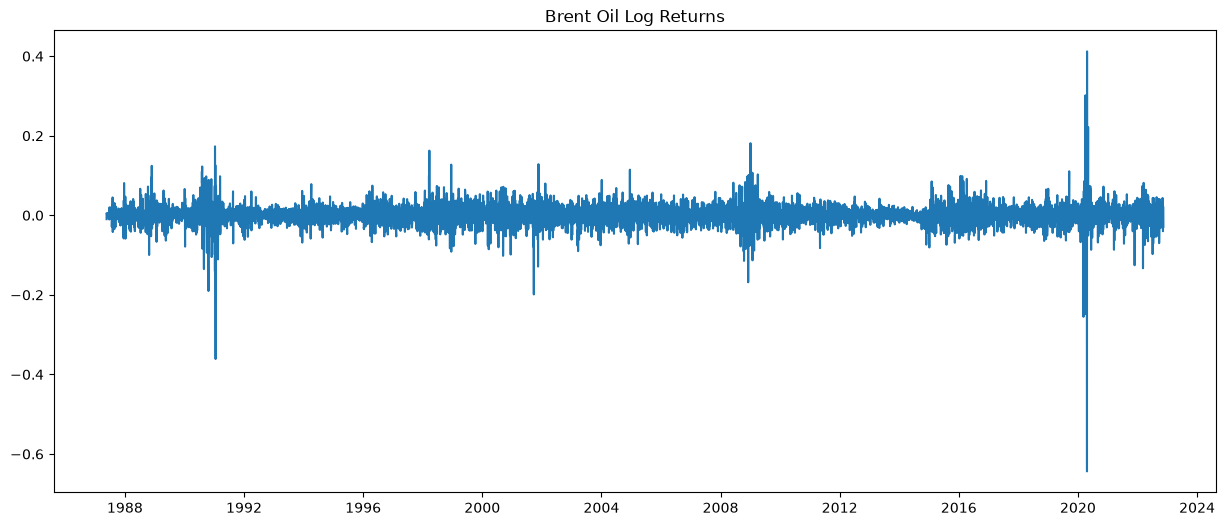

In [25]:
import numpy as np
# df = calculate_log_returns(df)
df["Log_Return"] = np.log(df["Price"]).diff()
plt.figure(figsize=(15,6))
plt.plot(df["Date"], df["Log_Return"])
plt.title("Brent Oil Log Returns")
plt.show()

In [ ]:
Stationarity

In [26]:
result = adfuller(df["Log_Return"].dropna())

print(result)

(np.float64(-16.427113494485894), np.float64(2.4985801611428892e-29), 28, 8981, {'1%': np.float64(-3.4310783342658615), '5%': np.float64(-2.861861876398633), '10%': np.float64(-2.566941329781918)}, np.float64(-40421.4169199348))


Volatility

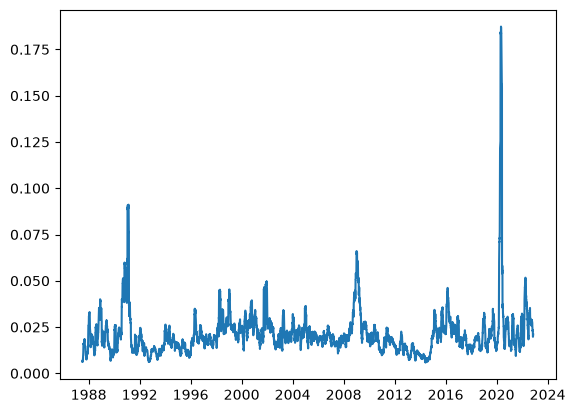

In [27]:
rolling_vol = df["Log_Return"].rolling(30).std()

plt.plot(df["Date"],rolling_vol)

# Time Series Property Analysis

## Trend Analysis

The raw Brent oil price series shows a changing trend over time.
The price does not remain around a fixed average value. Several major upward
and downward movements can be observed, especially during geopolitical conflicts,
economic crises, OPEC production decisions, and global supply disruptions.

These changes indicate that Brent oil prices experience different market regimes.

## Stationarity Analysis

A stationary time series has constant statistical properties such as mean and variance.

The raw Brent oil price series is non-stationary because:
- The average price changes over time.
- The variance changes during periods of market instability.
- The series contains long-term trends.

Because many statistical models require stationary data, log returns are calculated.
The log return series is closer to stationary because it fluctuates around a constant
mean without a strong long-term trend.

# Discussion

## Long-Term Trend
The Brent oil price series exhibits several long-term upward and downward movements driven by major geopolitical and economic events.

## Non-Stationarity of Raw Prices
The raw price series is non-stationary because its mean and variance change over time.

## Stationarity of Log Returns
The log return series fluctuates around a relatively constant mean and is therefore closer to being stationary.

## Volatility Clustering
Periods of large price movements are followed by additional large movements, indicating volatility clustering.

## Implications for Modeling
The presence of trends, structural shifts, and volatility patterns motivates the use of change point models to identify significant changes in the behavior of Brent oil prices.

In [8]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df["Price"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.9938560113924675
p-value: 0.28927350489340287


## ADF Test Interpretation

The Augmented Dickey-Fuller test helps determine whether a time series is stationary.

The raw price series generally fails the stationarity assumption because oil prices
contain trends and structural changes.

The log return series shows stronger evidence of stationarity, making it more suitable
for statistical modeling.

## Volatility Patterns

The log return plot shows periods of high and low volatility.

Large fluctuations appear during major market shocks, such as:
- Global Financial Crisis (2008)
- COVID-19 oil market collapse (2020)
- Russia-Ukraine conflict (2022)

This behavior is known as volatility clustering, where periods of high volatility
are followed by additional high volatility.

Understanding volatility patterns is important because structural changes in volatility
may indicate changes in market conditions.

# Change Point Model Understanding

## Purpose of Change Point Models

Change point models identify points in time where the statistical behavior of a
time series changes significantly.

For Brent oil prices, these models help detect structural breaks caused by events such as:
- Geopolitical conflicts
- OPEC production decisions
- Economic crises
- Supply disruptions

Instead of assuming the entire price series follows one pattern, change point models
allow different periods to have different characteristics.

## Expected Outputs

A change point analysis can provide:

### 1. Change Point Dates
Dates where significant changes in market behavior occurred.

### 2. Parameter Changes
Estimated differences before and after the change point, such as:
- Average price level
- Volatility
- Statistical distribution parameters

### 3. Probability Estimates
Bayesian models provide uncertainty estimates showing confidence in detected changes.

## Limitations

Change point detection identifies statistical changes but does not prove causation.

A detected change near an event only indicates that they occurred around the same time.
Additional economic analysis is required to confirm whether the event directly caused
the price movement.

In [28]:
df.to_csv("../data/processed/log_returns.csv",index=False)